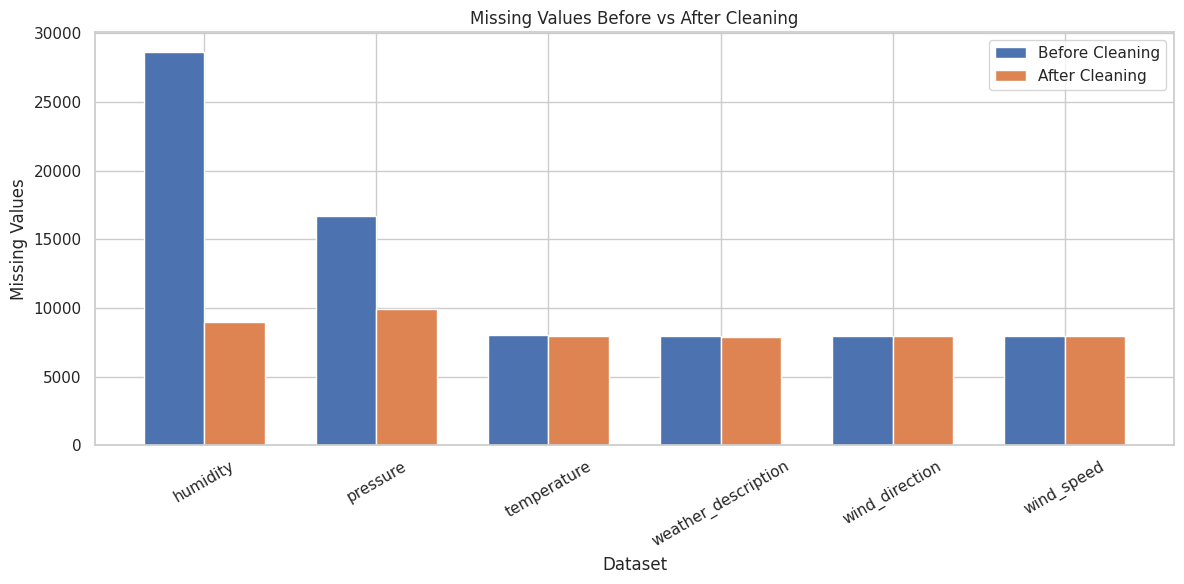

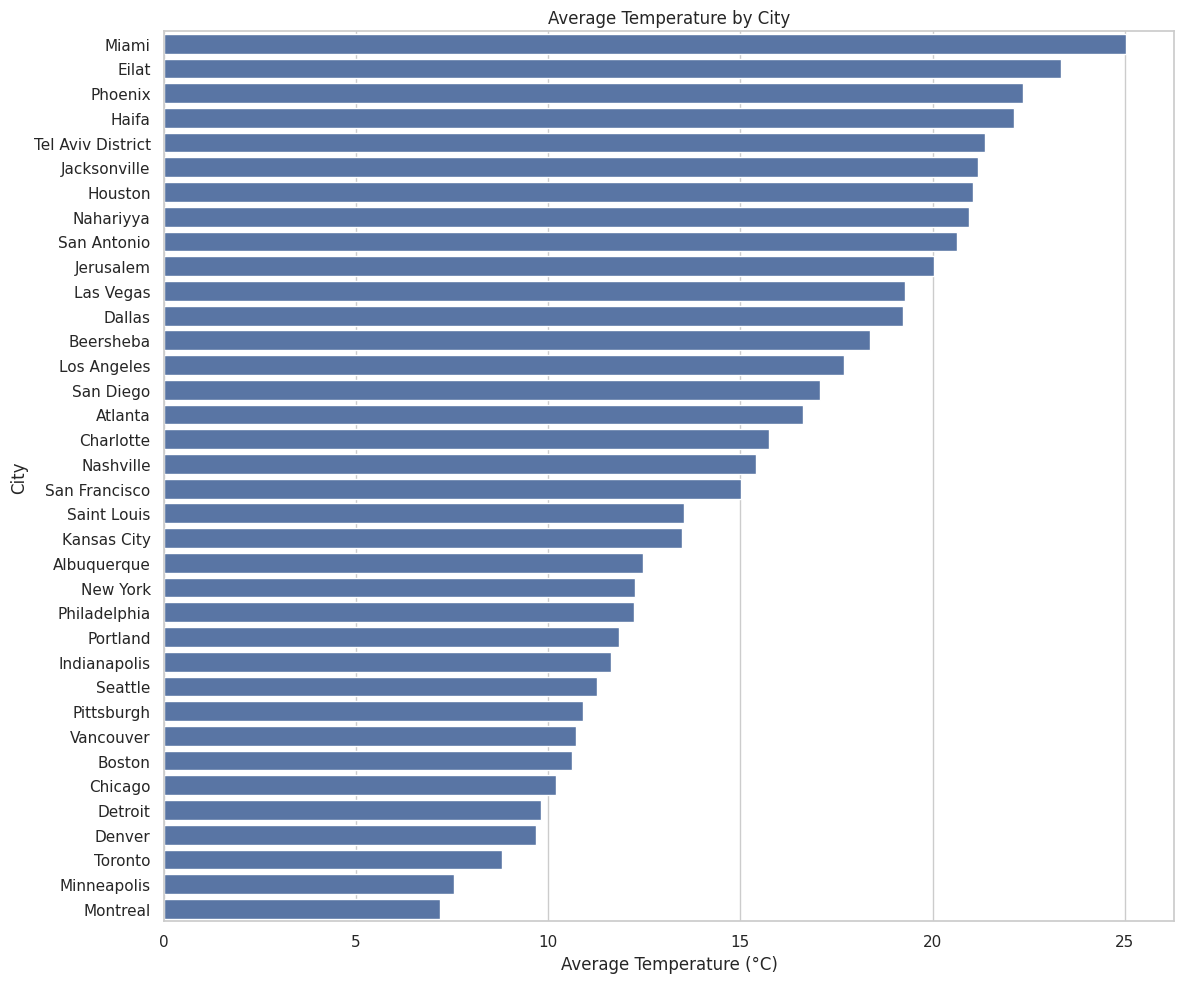

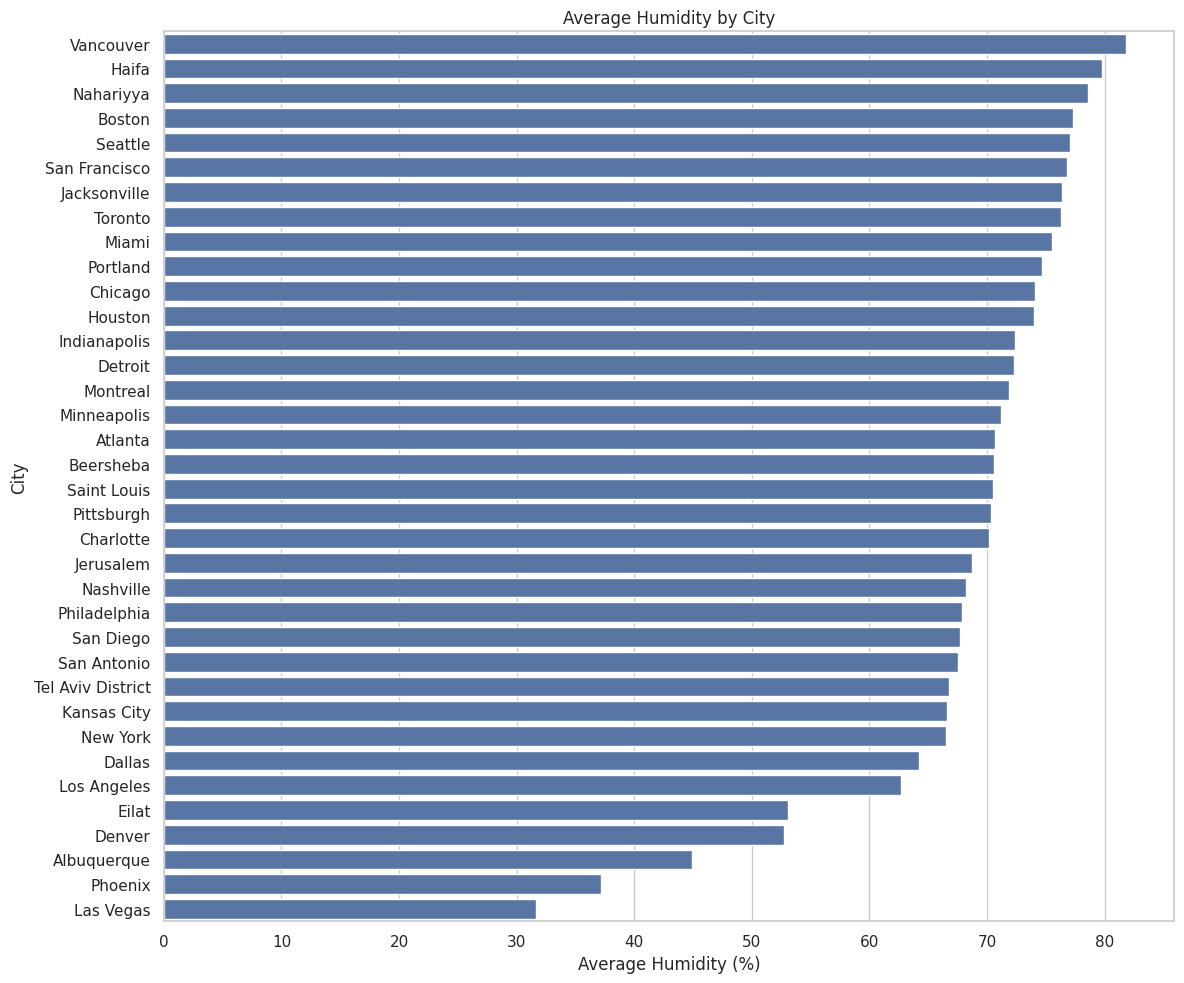

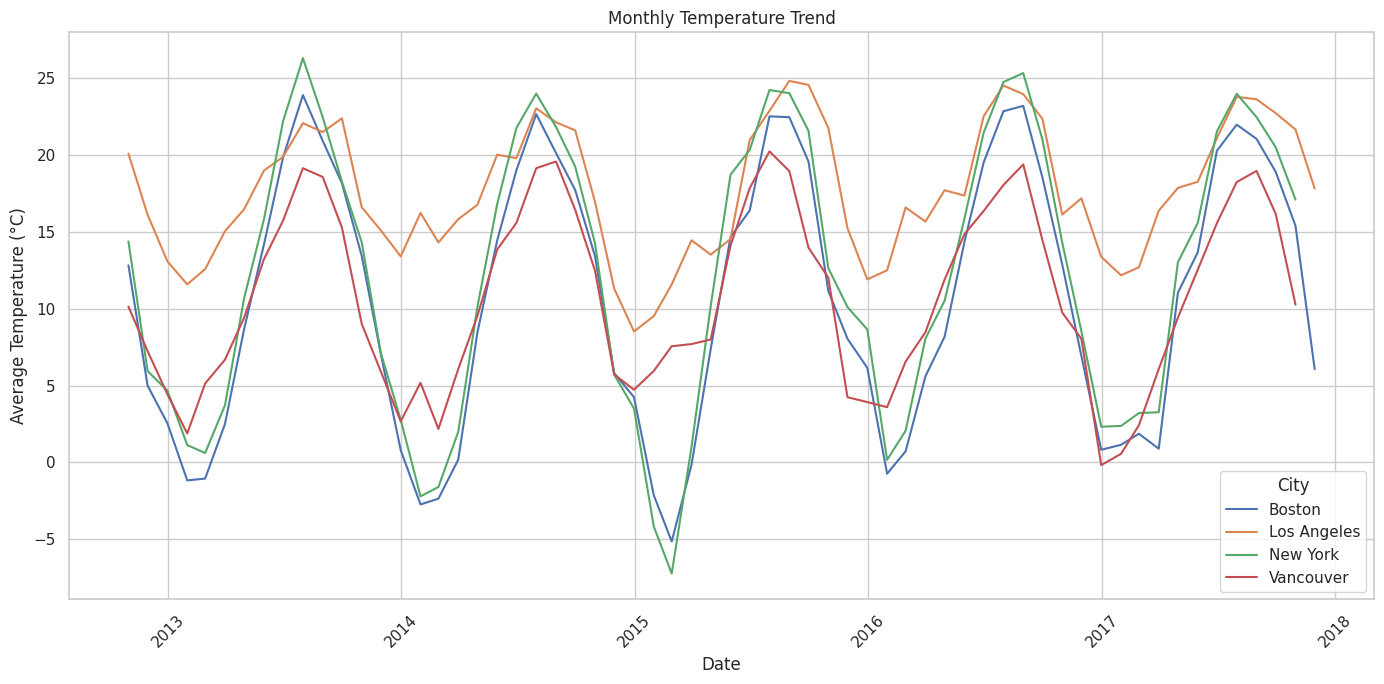

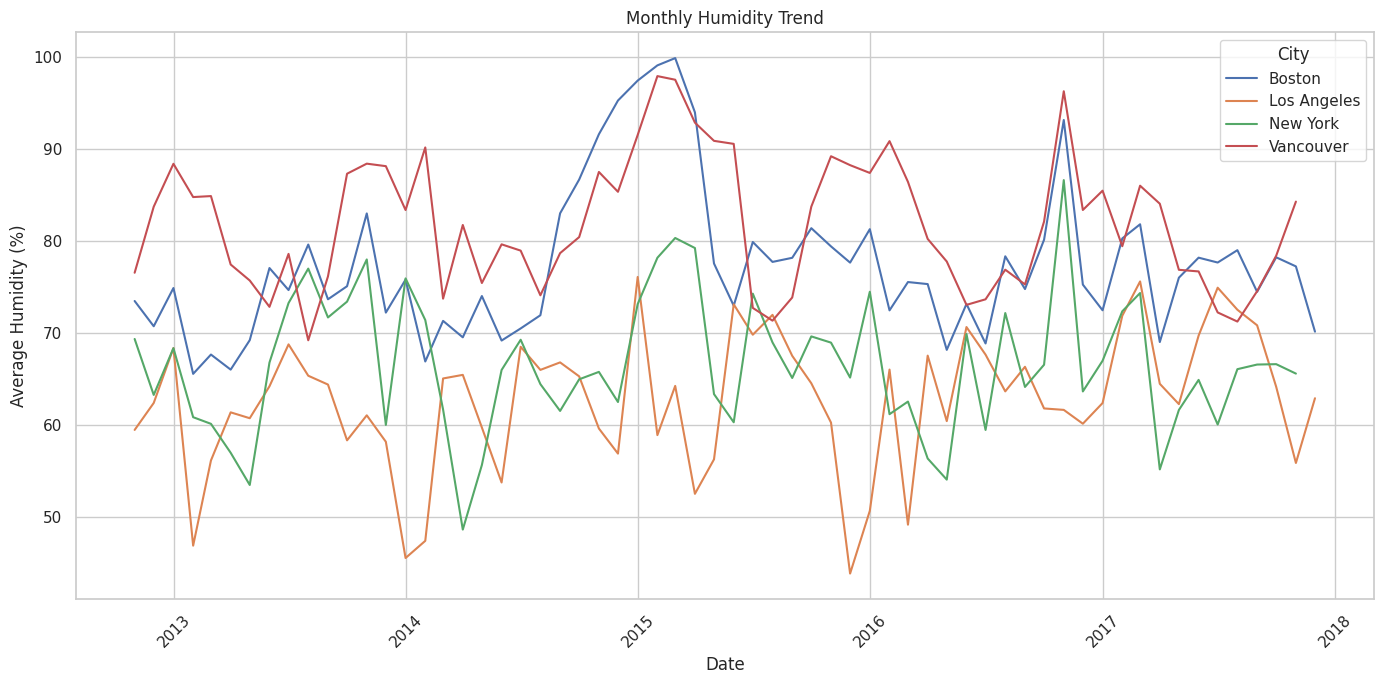

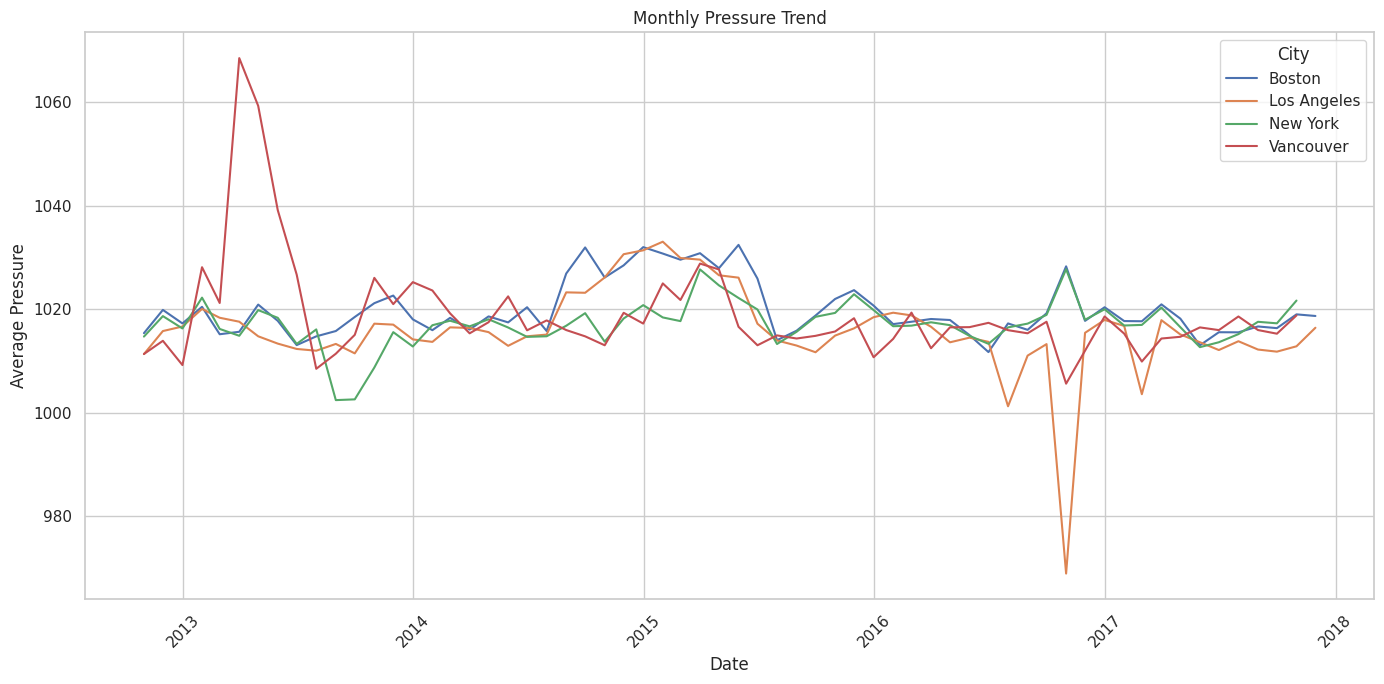

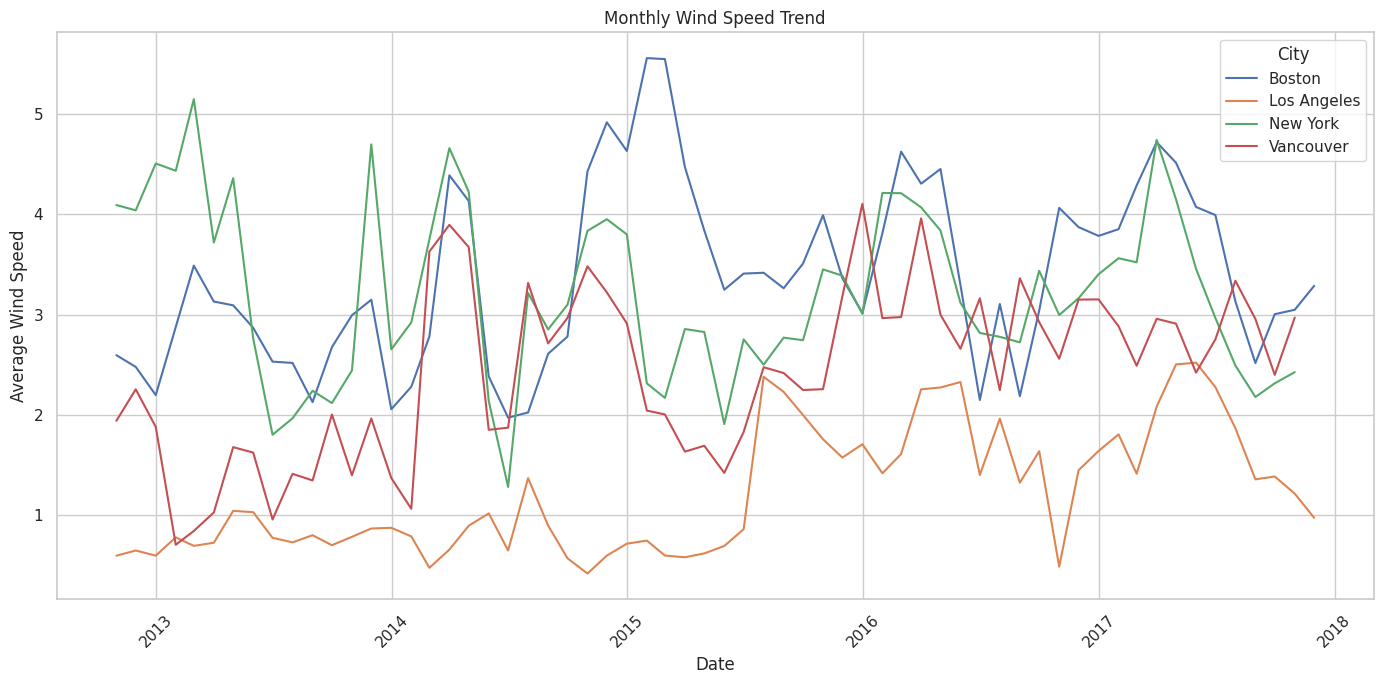

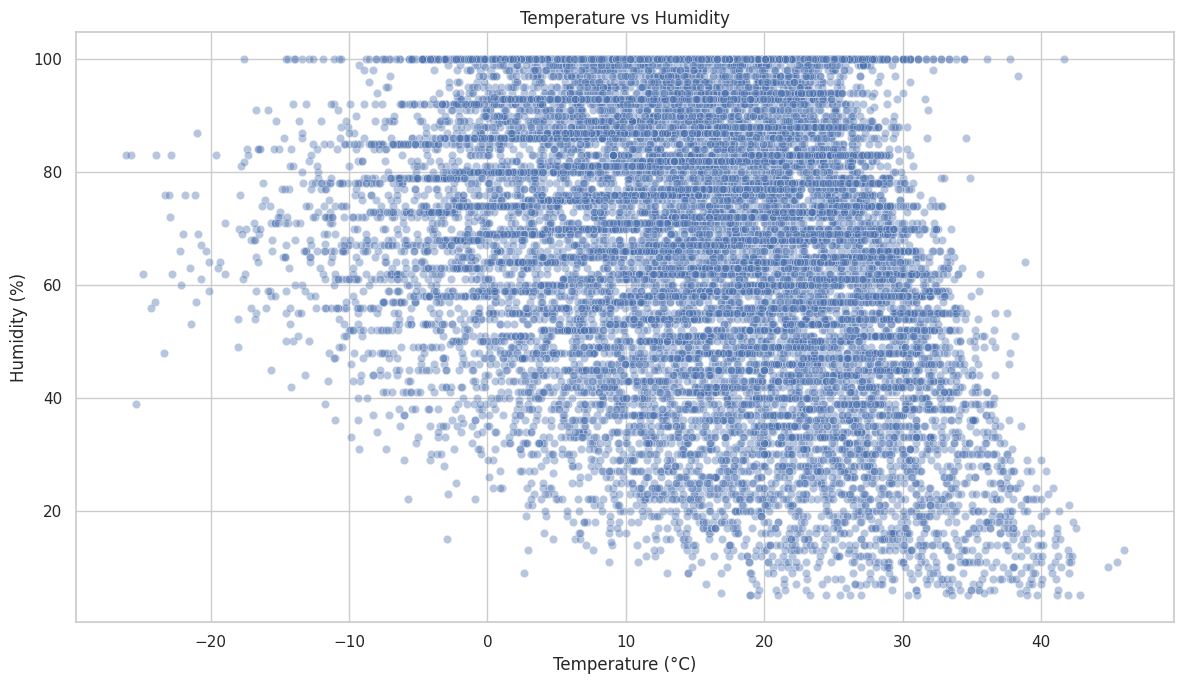

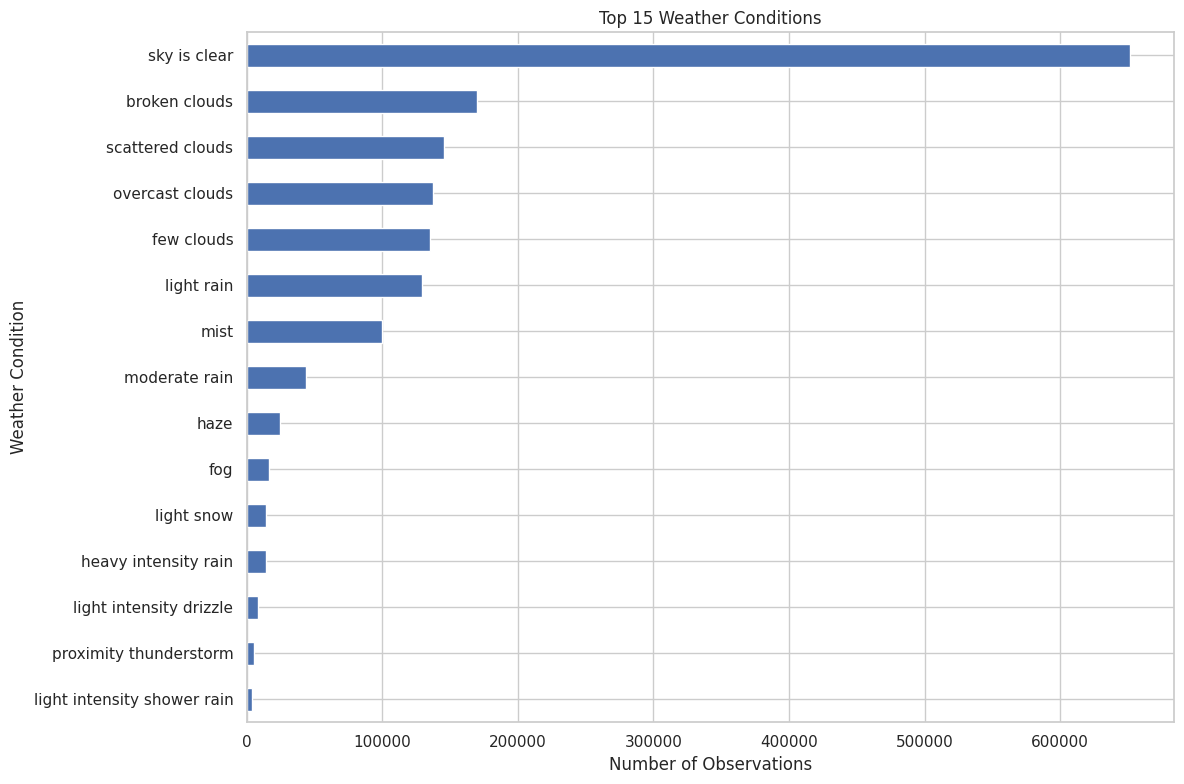

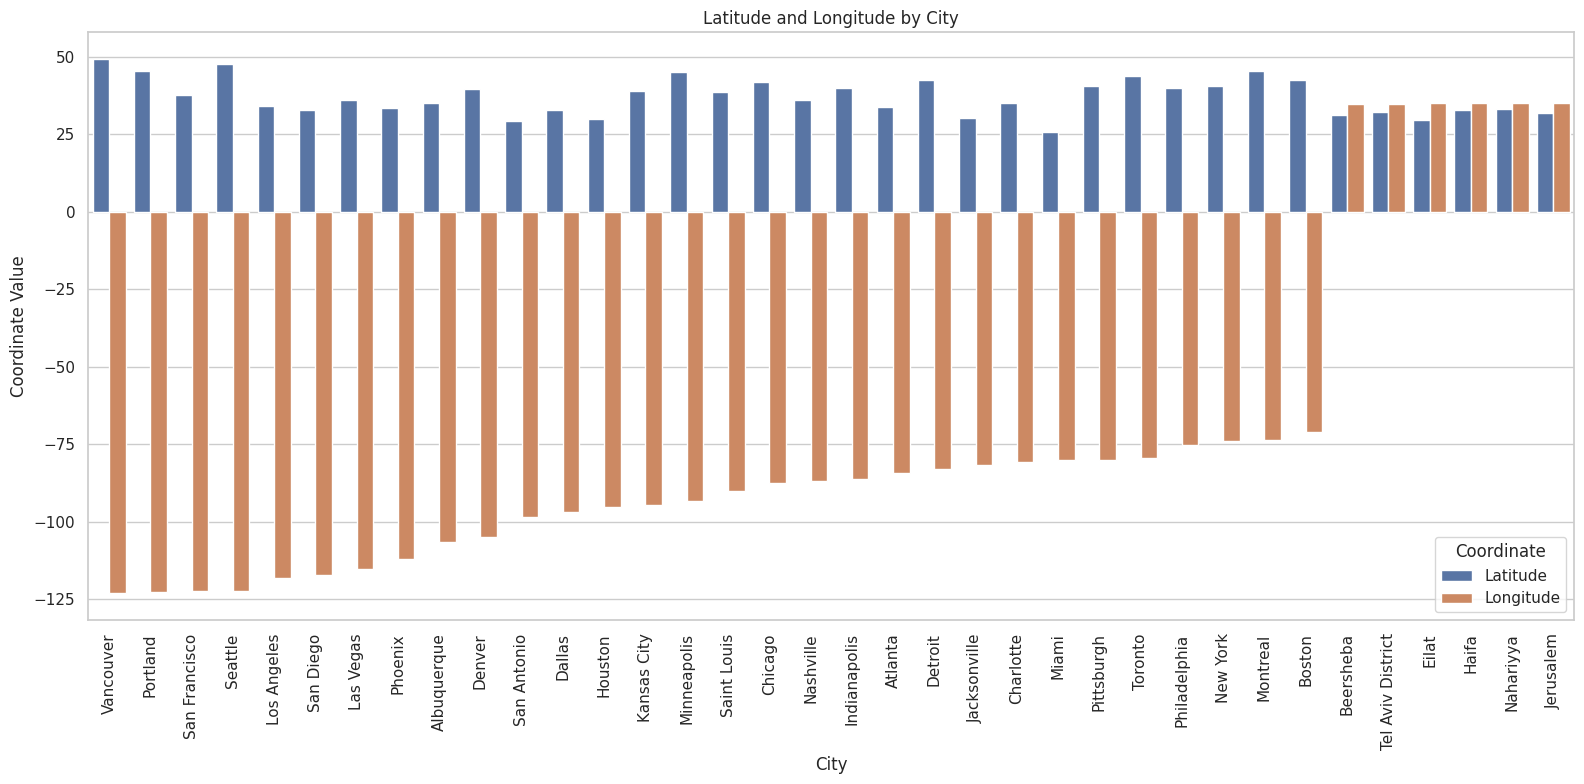

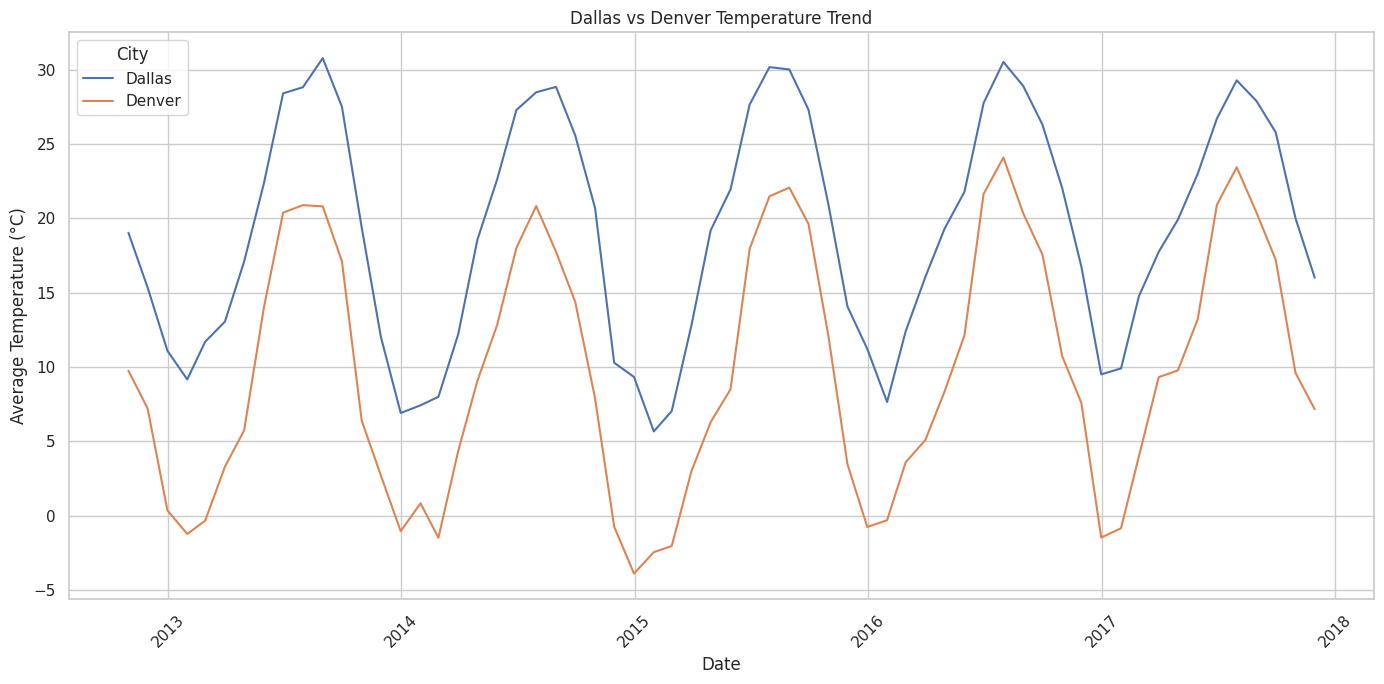

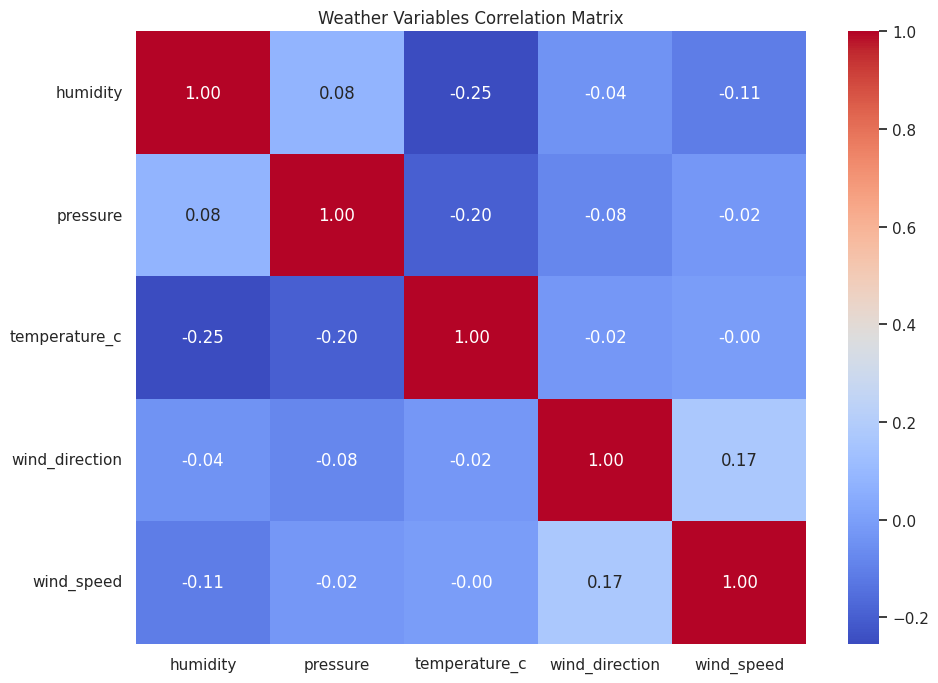


TASK COMPLETED

Final Cleaned Dataset: cleaned_output/cleaned_weather_data.csv
Quality Report: cleaned_output/data_quality_report.csv
Graphs Directory: cleaned_output/graphs


In [12]:

import os
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = "cleaned_output"
GRAPH_DIR = os.path.join(OUTPUT_DIR, "graphs")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")

FILES = {
    "humidity": "humidity.csv",
    "pressure": "pressure.csv",
    "temperature": "temperature.csv",
    "weather_description": "weather_description.csv",
    "wind_direction": "wind_direction.csv",
    "wind_speed": "wind_speed.csv"
}

CITY_FILE = "city_attributes.csv"

VALID_RANGES = {
    "humidity": (0, 100),
    "pressure": (800, 1200),
    "temperature": (180, 340),
    "wind_direction": (0, 360),
    "wind_speed": (0, None)
}

quality_report = []


def clean_numeric_file(file_path, metric):

    df = pd.read_csv(file_path)

    rows_before = len(df)
    columns_before = len(df.columns)
    duplicates_before = df.duplicated().sum()
    missing_before = df.isna().sum().sum()

    df = df.drop_duplicates().copy()

    df["datetime"] = pd.to_datetime(
        df["datetime"],
        errors="coerce"
    )

    invalid_dates = df["datetime"].isna().sum()

    df = df.dropna(subset=["datetime"])

    df = df.sort_values(
        "datetime"
    ).reset_index(drop=True)

    city_columns = [
        col
        for col in df.columns
        if col != "datetime"
    ]

    df[city_columns] = df[city_columns].apply(
        pd.to_numeric,
        errors="coerce"
    )

    df[city_columns] = df[city_columns].replace(
        [np.inf, -np.inf],
        np.nan
    )

    minimum, maximum = VALID_RANGES[metric]

    if minimum is not None:

        df[city_columns] = df[city_columns].where(
            df[city_columns] >= minimum
        )

    if maximum is not None:

        df[city_columns] = df[city_columns].where(
            df[city_columns] <= maximum
        )

    missing_after_validation = df.isna().sum().sum()

    df[city_columns] = df[city_columns].interpolate(
        method="linear",
        limit=6,
        limit_direction="both",
        limit_area="inside"
    )

    missing_after_cleaning = df.isna().sum().sum()

    df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            f"cleaned_{metric}.csv"
        ),
        index=False
    )

    quality_report.append({
        "Dataset": metric,
        "Rows Before": rows_before,
        "Columns": columns_before,
        "Duplicates Removed": int(duplicates_before),
        "Invalid Datetimes Removed": int(invalid_dates),
        "Missing Before": int(missing_before),
        "Missing After Validation": int(missing_after_validation),
        "Missing After Cleaning": int(missing_after_cleaning),
        "Rows After": len(df)
    })

    return df


def clean_description_file(file_path):

    df = pd.read_csv(file_path)

    rows_before = len(df)
    columns_before = len(df.columns)
    duplicates_before = df.duplicated().sum()
    missing_before = df.isna().sum().sum()

    df = df.drop_duplicates().copy()

    df["datetime"] = pd.to_datetime(
        df["datetime"],
        errors="coerce"
    )

    invalid_dates = df["datetime"].isna().sum()

    df = df.dropna(subset=["datetime"])

    df = df.sort_values(
        "datetime"
    ).reset_index(drop=True)

    city_columns = [
        col
        for col in df.columns
        if col != "datetime"
    ]

    for city in city_columns:

        df[city] = df[city].astype("string")

        df[city] = (
            df[city]
            .str.strip()
            .str.lower()
            .replace("", pd.NA)
        )

    df[city_columns] = df[city_columns].ffill(limit=6)

    missing_after_cleaning = df.isna().sum().sum()

    df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "cleaned_weather_description.csv"
        ),
        index=False
    )

    quality_report.append({
        "Dataset": "weather_description",
        "Rows Before": rows_before,
        "Columns": columns_before,
        "Duplicates Removed": int(duplicates_before),
        "Invalid Datetimes Removed": int(invalid_dates),
        "Missing Before": int(missing_before),
        "Missing After Validation": int(missing_before),
        "Missing After Cleaning": int(missing_after_cleaning),
        "Rows After": len(df)
    })

    return df


def clean_city_attributes(file_path):

    df = pd.read_csv(file_path)

    rows_before = len(df)
    columns_before = len(df.columns)
    duplicates_before = df.duplicated().sum()
    missing_before = df.isna().sum().sum()

    df = df.drop_duplicates().copy()

    df["City"] = df["City"].astype("string").str.strip()
    df["Country"] = df["Country"].astype("string").str.strip()

    df["Latitude"] = pd.to_numeric(
        df["Latitude"],
        errors="coerce"
    )

    df["Longitude"] = pd.to_numeric(
        df["Longitude"],
        errors="coerce"
    )

    df["Latitude"] = df["Latitude"].where(
        df["Latitude"].between(-90, 90)
    )

    df["Longitude"] = df["Longitude"].where(
        df["Longitude"].between(-180, 180)
    )

    duplicate_cities = df.duplicated(
        subset=["City"],
        keep="first"
    ).sum()

    df = df.drop_duplicates(
        subset=["City"],
        keep="first"
    )

    missing_after = df.isna().sum().sum()

    df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "cleaned_city_attributes.csv"
        ),
        index=False
    )

    quality_report.append({
        "Dataset": "city_attributes",
        "Rows Before": rows_before,
        "Columns": columns_before,
        "Duplicates Removed": int(
            duplicates_before + duplicate_cities
        ),
        "Invalid Datetimes Removed": 0,
        "Missing Before": int(missing_before),
        "Missing After Validation": int(missing_after),
        "Missing After Cleaning": int(missing_after),
        "Rows After": len(df)
    })

    return df


cleaned_data = {}

for metric, filename in FILES.items():

    if not os.path.exists(filename):

        raise FileNotFoundError(
            f"{filename} not found"
        )

    if metric == "weather_description":

        cleaned_data[metric] = clean_description_file(
            filename
        )

    else:

        cleaned_data[metric] = clean_numeric_file(
            filename,
            metric
        )


city_attributes = clean_city_attributes(CITY_FILE)


quality_df = pd.DataFrame(quality_report)

quality_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "data_quality_report.csv"
    ),
    index=False
)


expected_cities = set(
    city_attributes["City"]
)

city_consistency_report = []


for metric, df in cleaned_data.items():

    actual_cities = set(df.columns) - {"datetime"}

    missing_cities = expected_cities - actual_cities

    extra_cities = actual_cities - expected_cities

    city_consistency_report.append({
        "Dataset": metric,
        "Cities In Dataset": len(actual_cities),
        "Missing Cities": ", ".join(
            sorted(missing_cities)
        ),
        "Extra Cities": ", ".join(
            sorted(extra_cities)
        )
    })


city_consistency_df = pd.DataFrame(
    city_consistency_report
)

city_consistency_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "city_consistency_report.csv"
    ),
    index=False
)


long_data = []


for metric, df in cleaned_data.items():

    temp = df.melt(
        id_vars="datetime",
        var_name="City",
        value_name=metric
    )

    temp = temp.drop_duplicates(
        subset=["datetime", "City"]
    )

    long_data.append(temp)


weather = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["datetime", "City"],
        how="outer",
        validate="one_to_one"
    ),
    long_data
)


weather = weather.merge(
    city_attributes,
    on="City",
    how="left",
    validate="many_to_one"
)


weather["temperature_c"] = (
    weather["temperature"] - 273.15
)


weather["Year"] = weather["datetime"].dt.year
weather["Month"] = weather["datetime"].dt.month
weather["Month_Name"] = weather["datetime"].dt.month_name()
weather["Day"] = weather["datetime"].dt.day
weather["Hour"] = weather["datetime"].dt.hour


weather = weather.sort_values(
    ["datetime", "City"]
).reset_index(drop=True)


weather.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "cleaned_weather_data.csv"
    ),
    index=False
)


def save_graph(filename):

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            GRAPH_DIR,
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


missing_comparison = quality_df[
    quality_df["Dataset"] != "city_attributes"
].copy()


x = np.arange(
    len(missing_comparison)
)

width = 0.35


plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    missing_comparison["Missing Before"],
    width,
    label="Before Cleaning"
)

plt.bar(
    x + width / 2,
    missing_comparison["Missing After Cleaning"],
    width,
    label="After Cleaning"
)

plt.xticks(
    x,
    missing_comparison["Dataset"],
    rotation=30
)

plt.xlabel("Dataset")
plt.ylabel("Missing Values")

plt.title(
    "Missing Values Before vs After Cleaning"
)

plt.legend()

save_graph(
    "01_missing_values_before_after.png"
)


average_temperature = (
    weather
    .groupby(
        "City",
        as_index=False
    )["temperature_c"]
    .mean()
    .dropna()
    .sort_values(
        "temperature_c",
        ascending=False
    )
)


plt.figure(figsize=(12, 10))

sns.barplot(
    data=average_temperature,
    x="temperature_c",
    y="City"
)

plt.xlabel(
    "Average Temperature (°C)"
)

plt.ylabel("City")

plt.title(
    "Average Temperature by City"
)

save_graph(
    "02_average_temperature_by_city.png"
)


average_humidity = (
    weather
    .groupby(
        "City",
        as_index=False
    )["humidity"]
    .mean()
    .dropna()
    .sort_values(
        "humidity",
        ascending=False
    )
)


plt.figure(figsize=(12, 10))

sns.barplot(
    data=average_humidity,
    x="humidity",
    y="City"
)

plt.xlabel(
    "Average Humidity (%)"
)

plt.ylabel("City")

plt.title(
    "Average Humidity by City"
)

save_graph(
    "03_average_humidity_by_city.png"
)


selected_cities = [
    "Vancouver",
    "New York",
    "Los Angeles",
    "Boston"
]


temperature_trend = (
    weather[
        weather["City"].isin(
            selected_cities
        )
    ]
    .set_index("datetime")
    .groupby("City")[
        "temperature_c"
    ]
    .resample("ME")
    .mean()
    .reset_index()
)


plt.figure(figsize=(14, 7))

sns.lineplot(
    data=temperature_trend,
    x="datetime",
    y="temperature_c",
    hue="City"
)

plt.xlabel("Date")

plt.ylabel(
    "Average Temperature (°C)"
)

plt.title(
    "Monthly Temperature Trend"
)

plt.xticks(rotation=45)

save_graph(
    "04_monthly_temperature_trend.png"
)


humidity_trend = (
    weather[
        weather["City"].isin(
            selected_cities
        )
    ]
    .set_index("datetime")
    .groupby("City")[
        "humidity"
    ]
    .resample("ME")
    .mean()
    .reset_index()
)


plt.figure(figsize=(14, 7))

sns.lineplot(
    data=humidity_trend,
    x="datetime",
    y="humidity",
    hue="City"
)

plt.xlabel("Date")
plt.ylabel("Average Humidity (%)")

plt.title(
    "Monthly Humidity Trend"
)

plt.xticks(rotation=45)

save_graph(
    "05_monthly_humidity_trend.png"
)


pressure_trend = (
    weather[
        weather["City"].isin(
            selected_cities
        )
    ]
    .set_index("datetime")
    .groupby("City")[
        "pressure"
    ]
    .resample("ME")
    .mean()
    .reset_index()
)


plt.figure(figsize=(14, 7))

sns.lineplot(
    data=pressure_trend,
    x="datetime",
    y="pressure",
    hue="City"
)

plt.xlabel("Date")
plt.ylabel("Average Pressure")

plt.title(
    "Monthly Pressure Trend"
)

plt.xticks(rotation=45)

save_graph(
    "06_monthly_pressure_trend.png"
)


wind_trend = (
    weather[
        weather["City"].isin(
            selected_cities
        )
    ]
    .set_index("datetime")
    .groupby("City")[
        "wind_speed"
    ]
    .resample("ME")
    .mean()
    .reset_index()
)


plt.figure(figsize=(14, 7))

sns.lineplot(
    data=wind_trend,
    x="datetime",
    y="wind_speed",
    hue="City"
)

plt.xlabel("Date")
plt.ylabel("Average Wind Speed")

plt.title(
    "Monthly Wind Speed Trend"
)

plt.xticks(rotation=45)

save_graph(
    "07_monthly_wind_speed_trend.png"
)


scatter_data = weather.dropna(
    subset=[
        "temperature_c",
        "humidity"
    ]
)


if len(scatter_data) > 20000:

    scatter_data = scatter_data.sample(
        20000,
        random_state=42
    )


plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=scatter_data,
    x="temperature_c",
    y="humidity",
    alpha=0.4
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")

plt.title(
    "Temperature vs Humidity"
)

save_graph(
    "08_temperature_vs_humidity.png"
)


weather_conditions = (
    weather["weather_description"]
    .dropna()
    .value_counts()
    .head(15)
    .sort_values()
)


plt.figure(figsize=(12, 8))

weather_conditions.plot(
    kind="barh"
)

plt.xlabel(
    "Number of Observations"
)

plt.ylabel(
    "Weather Condition"
)

plt.title(
    "Top 15 Weather Conditions"
)

save_graph(
    "09_top_weather_conditions.png"
)


location_data = city_attributes.melt(
    id_vars="City",
    value_vars=[
        "Latitude",
        "Longitude"
    ],
    var_name="Coordinate",
    value_name="Value"
)


plt.figure(figsize=(16, 8))

sns.barplot(
    data=location_data,
    x="City",
    y="Value",
    hue="Coordinate"
)

plt.xlabel("City")
plt.ylabel("Coordinate Value")

plt.title(
    "Latitude and Longitude by City"
)

plt.xticks(rotation=90)

save_graph(
    "10_city_latitude_longitude.png"
)


comparison_cities = [
    "Dallas",
    "Denver"
]


dallas_denver = (
    weather[
        weather["City"].isin(
            comparison_cities
        )
    ]
    .set_index("datetime")
    .groupby("City")[
        "temperature_c"
    ]
    .resample("ME")
    .mean()
    .reset_index()
)


plt.figure(figsize=(14, 7))

sns.lineplot(
    data=dallas_denver,
    x="datetime",
    y="temperature_c",
    hue="City"
)

plt.xlabel("Date")

plt.ylabel(
    "Average Temperature (°C)"
)

plt.title(
    "Dallas vs Denver Temperature Trend"
)

plt.xticks(rotation=45)

save_graph(
    "11_dallas_vs_denver_temperature.png"
)


numeric_columns = [
    "humidity",
    "pressure",
    "temperature_c",
    "wind_direction",
    "wind_speed"
]


correlation_matrix = (
    weather[numeric_columns]
    .corr()
)


plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Weather Variables Correlation Matrix"
)

save_graph(
    "12_weather_correlation_heatmap.png"
)


print("\nTASK COMPLETED")

print(
    "\nFinal Cleaned Dataset:",
    os.path.join(
        OUTPUT_DIR,
        "cleaned_weather_data.csv"
    )
)

print(
    "Quality Report:",
    os.path.join(
        OUTPUT_DIR,
        "data_quality_report.csv"
    )
)

print(
    "Graphs Directory:",
    GRAPH_DIR
)

